# Self-Consistent High-Order Buchdahl Model Glass


By Ziyi Xiong 2026/4

## Theory

The model keeps the Zemax-style model-glass inputs independent:

$$
(n_d, V_d, \Delta P_{g,F})
$$

The refractive index is represented by a 6th-order Buchdahl polynomial:

$$
n(\lambda) = n_d + \sum_{k=1}^{6}\nu_k\omega^k
$$

where:

$$
\omega(\lambda) = \frac{\lambda - \lambda_d}{1 + \alpha(\lambda - \lambda_d)}
$$

The model-glass anchors are:

$$
n_F - n_C = \frac{n_d - 1}{V_d} = dn_{FC}
$$

$$
P_{g,F} = 0.6438 - 0.001682V_d + \Delta P_{g,F}
$$

$$
n_g - n_F = P_{g,F}\,dn_{FC} = dn_{gF}
$$

The high-order coefficients are fitted or regressed first:

$$
\nu_3, \nu_4, \nu_5, \nu_6
$$

Then $\nu_1$ and $\nu_2$ are solved from the two anchor equations. The high-order terms must be subtracted from the right-hand side:

$$
\nu_1(\omega_F-\omega_C) + \nu_2(\omega_F^2-\omega_C^2)
= dn_{FC} - \sum_{k=3}^{6}\nu_k(\omega_F^k-\omega_C^k)
$$

$$
\nu_1(\omega_g-\omega_F) + \nu_2(\omega_g^2-\omega_F^2)
= dn_{gF} - \sum_{k=3}^{6}\nu_k(\omega_g^k-\omega_F^k)
$$

The direct coefficient fit can be unweighted:

$$
\min_{\nu_3..\nu_6} \sum_i \left[n_{true}(\lambda_i)-n_{model}(\lambda_i)\right]^2
$$

or weighted:

$$
\min_{\nu_3..\nu_6} \sum_i w_i\left[n_{true}(\lambda_i)-n_{model}(\lambda_i)\right]^2
$$

The first weighted profile increases weight away from the d-line:

$$
w_i = 1 + s\left(\frac{|\lambda_i-\lambda_d|}{\max_j |\lambda_j-\lambda_d|}\right)^p
$$

with $s=20$ and $p=2$.

The heavy-IR profile keeps this base weight and adds extra weight past a chosen near-IR start wavelength:

$$
w_i^{heavy} = w_i + h\left[\max\left(0, \frac{\lambda_i-\lambda_{start}}{\lambda_{max}-\lambda_{start}}\right)\right]^q
$$

with $\lambda_{start}=1.2\,\mu m$, $h=200$, and $q=2$.

This intentionally relaxes some accuracy near $n_d$ and spends more of the fit budget at wavelengths far from $\lambda_d$, especially the bad near-IR points. The $d$, $F$, $C$, and $g$ model-glass anchors remain self-consistent because $\nu_1,\nu_2$ are still solved from the anchor equations after $\nu_3..\nu_6$ are selected.

The notebook now keeps the original unweighted model as a reference and compares it against the weighted and heavy-IR weighted models. For each profile, alpha is checked both at the direct per-glass fit layer and after fitting the runtime regression matrix.


In [1]:
from __future__ import annotations

from pathlib import Path
import copy
import importlib.util
import os

import matplotlib.pyplot as plt
import numpy as np
import yaml

# Spectral line wavelengths [um]
LAMBDA_d = 0.5875618   # d-line, yellow He
LAMBDA_g = 0.4358343   # g-line, blue Hg
LAMBDA_F = 0.4861327   # F-line, blue H
LAMBDA_C = 0.6562725   # C-line, red H

## Data Loading

In [2]:
if "OPTILAND_DB_ROOT" in os.environ:
    DB_ROOT = Path(os.environ["OPTILAND_DB_ROOT"])
else:
    _spec = importlib.util.find_spec("optiland")
    if _spec is None or _spec.origin is None:
        raise RuntimeError(
            "optiland not installed. Run `pip install optiland`, or set "
            "OPTILAND_DB_ROOT to the absolute path of optiland/database."
        )
    DB_ROOT = Path(_spec.origin).parent / "database"

GLASS_ROOT = DB_ROOT / "data-nk" / "glass"
print(GLASS_ROOT)


def sellmeier(wavelength, B1, C1, B2, C2, B3, C3):
    wavelength = np.asarray(wavelength, dtype=np.float64)
    wl2 = wavelength**2
    n2 = 1 + B1*wl2/(wl2-C1) + B2*wl2/(wl2-C2) + B3*wl2/(wl2-C3)
    return np.sqrt(n2)


def extract_glass_record(yml_path: Path):
    with yml_path.open("r", encoding="utf-8") as f:
        doc = yaml.safe_load(f)

    data_blocks = doc.get("DATA") or []
    if not data_blocks:
        return None
    formula = data_blocks[0]
    if formula.get("type") != "formula 2":
        return None

    coeffs = formula.get("coefficients", "").split()
    if len(coeffs) != 7:
        return None

    wavelength_range = formula.get("wavelength_range", "").strip().split()
    if len(wavelength_range) != 2:
        return None

    B1, C1 = float(coeffs[1]), float(coeffs[2])
    B2, C2 = float(coeffs[3]), float(coeffs[4])
    B3, C3 = float(coeffs[5]), float(coeffs[6])

    nd = float(sellmeier(LAMBDA_d, B1, C1, B2, C2, B3, C3))
    nF = float(sellmeier(LAMBDA_F, B1, C1, B2, C2, B3, C3))
    nC = float(sellmeier(LAMBDA_C, B1, C1, B2, C2, B3, C3))
    ng = float(sellmeier(LAMBDA_g, B1, C1, B2, C2, B3, C3))

    dn_FC = nF - nC
    if dn_FC < 1e-12:
        return None

    vd = (nd - 1.0) / dn_FC
    PgF = (ng - nF) / dn_FC
    dPgF = PgF - (0.6438 - 0.001682 * vd)

    specs = doc.get("SPECS", {})
    return {
        "name": yml_path.stem,
        "catalog": yml_path.parent.name,
        "wavelength_range": (float(wavelength_range[0]), float(wavelength_range[1])),
        "coeffs": {"B1": B1, "C1": C1, "B2": B2, "C2": C2, "B3": B3, "C3": C3},
        "nd": float(nd),
        "vd": float(vd),
        "dPgF": float(dPgF),
        "nd_stored": specs.get("nd"),
        "vd_stored": specs.get("Vd"),
        "dPgF_stored": specs.get("dPgF"),
    }


def load_all_glasses(root=GLASS_ROOT):
    records = []
    for yml_path in sorted(root.glob("*/*.yml")):
        try:
            rec = extract_glass_record(yml_path)
        except Exception:
            rec = None
        if rec is not None:
            records.append(rec)
    return records


glasses = load_all_glasses()
print(f"Loaded {len(glasses)} usable formula-2 glasses")

D:\Msc.Photonics\Master_Thesis\Optiland_Based\optiland_custom\optiland\database\data-nk\glass
Loaded 640 usable formula-2 glasses


In [3]:
# Filter to glasses covering the full model range and remove known bad dPgF records.
glasses_filtered = [
    g for g in glasses
    if g["wavelength_range"][0] <= 0.36501 and g["wavelength_range"][1] >= 2.3
]

before = len(glasses_filtered)
glasses_filtered = [
    g for g in glasses_filtered
    if g["dPgF_stored"] is None or abs(g["dPgF"] - g["dPgF_stored"]) < 0.05
]

print(f"After wavelength filtering and dPgF sanity filter: {len(glasses_filtered)} glasses")
print(f"Removed by dPgF sanity filter: {before - len(glasses_filtered)}")

After wavelength filtering and dPgF sanity filter: 536 glasses
Removed by dPgF sanity filter: 1


## Wavelength Grid And Buchdahl Helpers

In [4]:
wavelengths = np.array([
    0.36501, 0.40466, 0.43583, 0.48613, 0.54607,
    0.58756, 0.58929, 0.6328,  0.64385, 0.65627,
    0.70652, 0.85211, 1.01398, 1.060,   1.52958,
    1.97009, 2.3,
], dtype=np.float64)


def get_indices(glass, wavelengths):
    c = glass["coeffs"]
    return sellmeier(wavelengths, c["B1"], c["C1"], c["B2"], c["C2"], c["B3"], c["C3"])


def buchdahl_omega(lam, alpha, lam_d=LAMBDA_d):
    lam = np.asarray(lam, dtype=np.float64)
    dl = lam - lam_d
    return dl / (1.0 + alpha * dl)


def buchdahl_eval(nd, coeffs, omega):
    omega = np.asarray(omega, dtype=np.float64)
    n = np.full_like(omega, nd, dtype=np.float64)
    for k, coeff in enumerate(coeffs, start=1):
        n += coeff * omega**k
    return n


def feature_vec_20(nd, vd, dPgF):
    return np.array([
        1.0, nd, vd, dPgF, nd**2, vd**2, dPgF**2, nd*vd, nd*dPgF, vd*dPgF,
        nd**3, vd**3, dPgF**3, nd**2*vd, nd**2*dPgF, vd**2*nd, vd**2*dPgF,
        dPgF**2*nd, dPgF**2*vd, nd*vd*dPgF,
    ], dtype=np.float64)


def feature_vec_10(nd, vd, dPgF):
    return np.array([
        1.0, nd, vd, dPgF, nd**2, vd**2, dPgF**2, nd*vd, nd*dPgF, vd*dPgF,
    ], dtype=np.float64)

## Self-Consistent High-Order Solver


In [5]:
def solve_nu12_conditioned_high(nd, vd, dPgF, nu_high, alpha):
    """Solve nu1,nu2 conditioned on nu3..nuN."""
    wg = float(buchdahl_omega(LAMBDA_g, alpha))
    wF = float(buchdahl_omega(LAMBDA_F, alpha))
    wC = float(buchdahl_omega(LAMBDA_C, alpha))

    dn_FC = (nd - 1.0) / vd
    PgF = 0.6438 - 0.001682 * vd + dPgF
    dn_gF = PgF * dn_FC

    M = np.array([
        [wF - wC, wF**2 - wC**2],
        [wg - wF, wg**2 - wF**2],
    ], dtype=np.float64)

    corr_FC = 0.0
    corr_gF = 0.0
    for power, coeff in enumerate(nu_high, start=3):
        corr_FC += coeff * (wF**power - wC**power)
        corr_gF += coeff * (wg**power - wF**power)

    rhs = np.array([dn_FC - corr_FC, dn_gF - corr_gF], dtype=np.float64)
    return np.linalg.solve(M, rhs)


def self_consistent_coeffs_high(nd, vd, dPgF, nu_high, alpha):
    nu1, nu2 = solve_nu12_conditioned_high(nd, vd, dPgF, nu_high, alpha)
    return np.concatenate([[nu1, nu2], np.asarray(nu_high, dtype=np.float64)])


def predict_self_consistent_high(nd, vd, dPgF, nu_high, wavelength, alpha):
    omega = buchdahl_omega(wavelength, alpha)
    coeffs = self_consistent_coeffs_high(nd, vd, dPgF, nu_high, alpha)
    return buchdahl_eval(nd, coeffs, omega)


def wavelength_weights(wths, strength=20.0, power=2.0, center=LAMBDA_d):
    wths = np.asarray(wths, dtype=np.float64)
    distance = np.abs(wths - center)
    scale = distance.max()
    if scale == 0:
        return np.ones_like(wths)
    return 1.0 + strength * (distance / scale) ** power


def heavy_ir_weights(wths, base_strength=20.0, base_power=2.0, ir_start=1.2, ir_strength=200.0, ir_power=2.0):
    wths = np.asarray(wths, dtype=np.float64)
    weights = wavelength_weights(wths, strength=base_strength, power=base_power)
    denom = wths.max() - ir_start
    if denom <= 0:
        return weights
    ir_coord = np.clip((wths - ir_start) / denom, 0.0, 1.0)
    return weights + ir_strength * ir_coord**ir_power


def fit_self_consistent_nu_high(nd, vd, dPgF, n_true, omega, alpha, order, weights=None):
    """Fit nu3..nu_order while enforcing anchors exactly."""
    num_high = order - 2
    base = np.zeros(num_high)
    coeff_base = self_consistent_coeffs_high(nd, vd, dPgF, base, alpha)
    n_base = buchdahl_eval(nd, coeff_base, omega)

    cols = []
    for j in range(num_high):
        nu_high = np.zeros(num_high)
        nu_high[j] = 1.0
        coeff_j = self_consistent_coeffs_high(nd, vd, dPgF, nu_high, alpha)
        cols.append(buchdahl_eval(nd, coeff_j, omega) - n_base)

    A = np.column_stack(cols)
    target = n_true - n_base

    if weights is not None:
        sqrt_w = np.sqrt(np.asarray(weights, dtype=np.float64))
        A = A * sqrt_w[:, None]
        target = target * sqrt_w

    nu_high, *_ = np.linalg.lstsq(A, target, rcond=None)
    return nu_high


def anchor_report_high(nd, vd, dPgF, nu_high, alpha):
    coeffs = self_consistent_coeffs_high(nd, vd, dPgF, nu_high, alpha)
    nd_model = float(buchdahl_eval(nd, coeffs, buchdahl_omega(LAMBDA_d, alpha)))
    nF = float(buchdahl_eval(nd, coeffs, buchdahl_omega(LAMBDA_F, alpha)))
    nC = float(buchdahl_eval(nd, coeffs, buchdahl_omega(LAMBDA_C, alpha)))
    ng = float(buchdahl_eval(nd, coeffs, buchdahl_omega(LAMBDA_g, alpha)))
    vd_model = (nd_model - 1.0) / (nF - nC)
    pgf_model = (ng - nF) / (nF - nC)
    dpgf_model = pgf_model - (0.6438 - 0.001682 * vd_model)
    return nd_model, vd_model, dpgf_model


def build_training_targets_high(alpha, order, weights=None):
    omega = buchdahl_omega(wavelengths, alpha)
    targets = []
    fit_errors = []
    for g in glasses_filtered:
        n_true = get_indices(g, wavelengths)
        nu_high = fit_self_consistent_nu_high(
            g["nd"], g["vd"], g["dPgF"], n_true, omega, alpha, order=order, weights=weights
        )
        targets.append(nu_high)
        n_pred = predict_self_consistent_high(
            g["nd"], g["vd"], g["dPgF"], nu_high, wavelengths, alpha
        )
        fit_errors.append(np.max(np.abs(n_true - n_pred)))
    return np.vstack(targets), np.array(fit_errors)


def sweep_alpha_high(order, alphas=np.linspace(0.5, 5.0, 60), weights=None):
    results = []
    for alpha in alphas:
        _, errs = build_training_targets_high(alpha=alpha, order=order, weights=weights)
        results.append((alpha, errs.max(), errs.mean(), np.median(errs)))
    results = np.array(results)
    best_idx = int(np.argmin(results[:, 1]))
    return float(results[best_idx, 0]), results


def regress_high_order(Y, feature_func=feature_vec_20):
    Phi = np.vstack([feature_func(g["nd"], g["vd"], g["dPgF"]) for g in glasses_filtered])
    return Phi, np.linalg.lstsq(Phi, Y, rcond=None)[0]


def predict_from_regression_high(g, wavelength, alpha, A, feature_func=feature_vec_20):
    phi = feature_func(g["nd"], g["vd"], g["dPgF"])
    nu_high = phi @ A
    return predict_self_consistent_high(g["nd"], g["vd"], g["dPgF"], nu_high, wavelength, alpha)


def end_to_end_errors_high(wths, alpha, A, feature_func=feature_vec_20):
    errs = []
    for g in glasses_filtered:
        n_true = get_indices(g, wths)
        n_pred = predict_from_regression_high(g, wths, alpha, A, feature_func)
        errs.append(np.max(np.abs(n_true - n_pred)))
    return np.array(errs)


def print_regression_coeff_errors(name, Phi, Y, A):
    pred = Phi @ A
    err = np.abs(pred - Y)
    print(f"\n{name}")
    for k in range(err.shape[1]):
        print(f"  nu{k+3}: max={err[:, k].max():.3e}, mean={err[:, k].mean():.3e}")


wth_shift = wavelengths + 0.01


## 6th-Order Experiment

This fits and regresses $\nu_3..\nu_6$, then solves $\nu_1,\nu_2$ from the anchor equations.


Fit weights
wavelength_um   weighted   heavy_IR
     0.36501     1.3378     1.3378
     0.40466     1.2282     1.2282
     0.43583     1.1570     1.1570
     0.48613     1.0702     1.0702
     0.54607     1.0117     1.0117
     0.58756     1.0000     1.0000
     0.58929     1.0000     1.0000
     0.63280     1.0140     1.0140
     0.64385     1.0216     1.0216
     0.65627     1.0322     1.0322
     0.70652     1.0965     1.0965
     0.85211     1.4773     1.4773
     1.01398     2.2401     2.2401
     1.06000     2.5223     2.5223
     1.52958     7.0523    25.0065
     1.97009    14.0361   112.0590
     2.30000    21.0000   221.0000

6th-order unweighted fit-layer quality, no regression yet
alpha=2.5: max=1.420e-03, mean=9.964e-04, median=9.874e-04
alpha=1.492: max=4.063e-04, mean=2.204e-04, median=2.177e-04

6th unweighted alpha=2.5 20dim
  nu3: max=4.201e-02, mean=4.069e-03
  nu4: max=7.078e-02, mean=1.165e-02
  nu5: max=7.576e-01, mean=1.249e-01
  nu6: max=1.070e+00, mean=1.782e-0

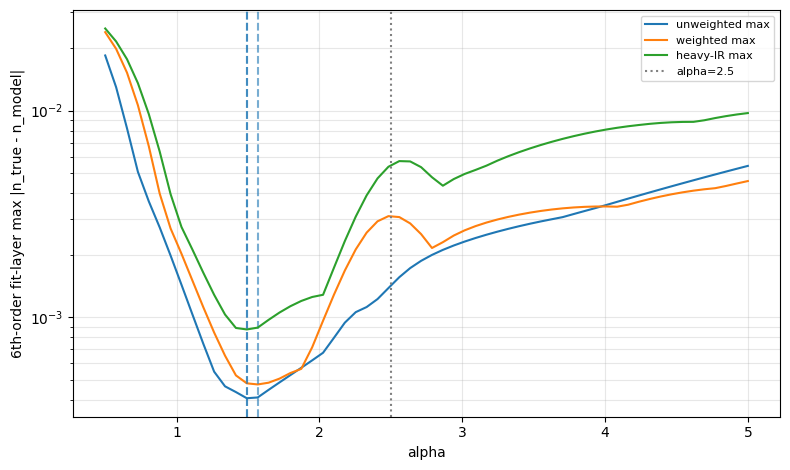

In [6]:
BASE_WEIGHT_STRENGTH = 20.0
BASE_WEIGHT_POWER = 2.0
HEAVY_IR_START = 1.2
HEAVY_IR_STRENGTH = 200.0
HEAVY_IR_POWER = 2.0

UNWEIGHTED_WEIGHTS = None
BASE_WEIGHTS = wavelength_weights(wavelengths, strength=BASE_WEIGHT_STRENGTH, power=BASE_WEIGHT_POWER)
HEAVY_IR_WEIGHTS = heavy_ir_weights(
    wavelengths,
    base_strength=BASE_WEIGHT_STRENGTH,
    base_power=BASE_WEIGHT_POWER,
    ir_start=HEAVY_IR_START,
    ir_strength=HEAVY_IR_STRENGTH,
    ir_power=HEAVY_IR_POWER,
)

WEIGHT_PROFILES = [
    ("unweighted", UNWEIGHTED_WEIGHTS),
    ("weighted", BASE_WEIGHTS),
    ("heavy-IR", HEAVY_IR_WEIGHTS),
]

print("Fit weights")
print("wavelength_um   weighted   heavy_IR")
for w, base_w, heavy_w in zip(wavelengths, BASE_WEIGHTS, HEAVY_IR_WEIGHTS):
    print(f"{w:12.5f} {base_w:10.4f} {heavy_w:10.4f}")

profile_results = {}
cases6 = []
Phi20 = None

for profile_name, weights in WEIGHT_PROFILES:
    Y25, fit25 = build_training_targets_high(alpha=2.5, order=6, weights=weights)
    alpha_opt, alpha_results = sweep_alpha_high(order=6, weights=weights)
    Yopt, fitopt = build_training_targets_high(alpha=alpha_opt, order=6, weights=weights)

    Phi20, A25 = regress_high_order(Y25)
    _, Aopt = regress_high_order(Yopt)

    profile_results[profile_name] = {
        "weights": weights,
        "Y25": Y25,
        "fit25": fit25,
        "alpha_opt": alpha_opt,
        "alpha_results": alpha_results,
        "Yopt": Yopt,
        "fitopt": fitopt,
        "A25": A25,
        "Aopt": Aopt,
    }

    print(f"\n6th-order {profile_name} fit-layer quality, no regression yet")
    print(f"alpha=2.5: max={fit25.max():.3e}, mean={fit25.mean():.3e}, median={np.median(fit25):.3e}")
    print(f"alpha={alpha_opt:.3f}: max={fitopt.max():.3e}, mean={fitopt.mean():.3e}, median={np.median(fitopt):.3e}")

    print_regression_coeff_errors(f"6th {profile_name} alpha=2.5 20dim", Phi20, Y25, A25)
    print_regression_coeff_errors(f"6th {profile_name} alpha={alpha_opt:.3f} 20dim", Phi20, Yopt, Aopt)

    cases6.append((f"6th {profile_name} alpha={alpha_opt:.3f} 20dim", 6, alpha_opt, Aopt))

fig, ax = plt.subplots(figsize=(8, 4.8))
for profile_name, result in profile_results.items():
    alpha_results = result["alpha_results"]
    ax.semilogy(alpha_results[:, 0], alpha_results[:, 1], label=f"{profile_name} max")
    ax.axvline(result["alpha_opt"], ls="--", alpha=0.6)
ax.axvline(2.5, color="gray", ls=":", label="alpha=2.5")
ax.set_xlabel("alpha")
ax.set_ylabel("6th-order fit-layer max |n_true - n_model|")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

# Named aliases used by the save cell.
ALPHA6_REF_OPT = profile_results["unweighted"]["alpha_opt"]
A6_ref_opt_20 = profile_results["unweighted"]["Aopt"]
ALPHA6_OPT = profile_results["weighted"]["alpha_opt"]
A6_opt_20 = profile_results["weighted"]["Aopt"]
ALPHA6_HEAVY_OPT = profile_results["heavy-IR"]["alpha_opt"]
A6_heavy_opt_20 = profile_results["heavy-IR"]["Aopt"]


## 6th-Order Regression-Level Alpha Sweep

The fit-level alpha sweep optimizes the direct per-glass fit. This sweep optimizes alpha after fitting the runtime regression matrix, which is the quantity used by `ModelMaterial`.

The validation grid includes the shifted wavelengths and 1.55 um, but does not give 1.55 extra weight.



Best 6th-order unweighted alpha after regression by worst validation error: 1.4915
runtime max=3.971e-03, mean=7.600e-04, median=5.458e-04, p95=1.995e-03

Best 6th-order weighted alpha after regression by worst validation error: 1.4915
runtime max=3.892e-03, mean=7.184e-04, median=4.839e-04, p95=1.996e-03

Best 6th-order heavy-IR alpha after regression by worst validation error: 1.4915
runtime max=3.856e-03, mean=7.980e-04, median=5.781e-04, p95=2.016e-03


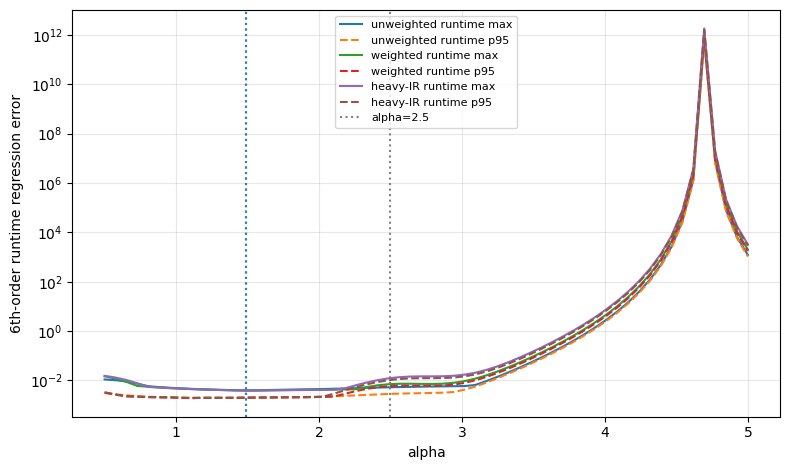

In [7]:
wth_validation = np.unique(np.concatenate([wth_shift, np.array([1.55], dtype=np.float64)]))

def sweep_alpha_high_regression(order, alphas=np.linspace(0.5, 5.0, 60), validation_wths=wth_validation, weights=None):
    results = []
    matrices = []
    for alpha in alphas:
        Y, fit_errors = build_training_targets_high(alpha=alpha, order=order, weights=weights)
        _, A = regress_high_order(Y)
        runtime_errors = end_to_end_errors_high(validation_wths, alpha, A)
        results.append((
            alpha,
            runtime_errors.max(),
            runtime_errors.mean(),
            np.median(runtime_errors),
            np.percentile(runtime_errors, 95),
            fit_errors.max(),
        ))
        matrices.append(A)
    results = np.array(results)
    best_idx = int(np.argmin(results[:, 1]))
    return float(results[best_idx, 0]), results, matrices[best_idx]

reg_profile_results = {}

for profile_name, result in profile_results.items():
    alpha_reg_opt, alpha_reg_results, Areg = sweep_alpha_high_regression(order=6, weights=result["weights"])
    best_idx = int(np.argmin(alpha_reg_results[:, 1]))
    reg_profile_results[profile_name] = {
        "alpha_reg_opt": alpha_reg_opt,
        "alpha_reg_results": alpha_reg_results,
        "Areg": Areg,
    }

    print(f"\nBest 6th-order {profile_name} alpha after regression by worst validation error: {alpha_reg_opt:.4f}")
    print(
        f"runtime max={alpha_reg_results[best_idx,1]:.3e}, "
        f"mean={alpha_reg_results[best_idx,2]:.3e}, "
        f"median={alpha_reg_results[best_idx,3]:.3e}, "
        f"p95={alpha_reg_results[best_idx,4]:.3e}"
    )

    cases6.append((f"6th {profile_name} alpha={alpha_reg_opt:.3f} 20dim reg-opt", 6, alpha_reg_opt, Areg))

fig, ax = plt.subplots(figsize=(8, 4.8))
for profile_name, result in reg_profile_results.items():
    alpha_reg_results = result["alpha_reg_results"]
    ax.semilogy(alpha_reg_results[:, 0], alpha_reg_results[:, 1], label=f"{profile_name} runtime max")
    ax.semilogy(alpha_reg_results[:, 0], alpha_reg_results[:, 4], ls="--", label=f"{profile_name} runtime p95")
    ax.axvline(result["alpha_reg_opt"], ls=":", alpha=0.6)
ax.axvline(2.5, color="gray", ls=":", label="alpha=2.5")
ax.set_xlabel("alpha")
ax.set_ylabel("6th-order runtime regression error")
ax.grid(True, which="both", alpha=0.3)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

ALPHA6_REF_REG_OPT = reg_profile_results["unweighted"]["alpha_reg_opt"]
A6_ref_reg_opt_20 = reg_profile_results["unweighted"]["Areg"]
ALPHA6_REG_OPT = reg_profile_results["weighted"]["alpha_reg_opt"]
A6_reg_opt_20 = reg_profile_results["weighted"]["Areg"]
ALPHA6_HEAVY_REG_OPT = reg_profile_results["heavy-IR"]["alpha_reg_opt"]
A6_heavy_reg_opt_20 = reg_profile_results["heavy-IR"]["Areg"]


## End-To-End Regression Validation



training wavelengths
6th unweighted alpha=1.492 20dim               max=3.9135e-03 mean=7.4434e-04 median=5.3789e-04 p95=1.9772e-03
6th weighted alpha=1.568 20dim                 max=3.8552e-03 mean=7.1772e-04 median=4.8127e-04 p95=1.9779e-03
6th heavy-IR alpha=1.492 20dim                 max=3.8103e-03 mean=7.8986e-04 median=5.7159e-04 p95=1.9836e-03
6th unweighted alpha=1.492 20dim reg-opt       max=3.9135e-03 mean=7.4434e-04 median=5.3789e-04 p95=1.9772e-03
6th weighted alpha=1.492 20dim reg-opt         max=3.8410e-03 mean=7.0835e-04 median=4.7903e-04 p95=1.9753e-03
6th heavy-IR alpha=1.492 20dim reg-opt         max=3.8103e-03 mean=7.8986e-04 median=5.7159e-04 p95=1.9836e-03

shifted wavelengths
6th unweighted alpha=1.492 20dim               max=3.9706e-03 mean=7.5998e-04 median=5.4580e-04 p95=1.9950e-03
6th weighted alpha=1.568 20dim                 max=3.9192e-03 mean=7.2788e-04 median=4.9138e-04 p95=2.0048e-03
6th heavy-IR alpha=1.492 20dim                 max=3.8563e-03 mean=7.

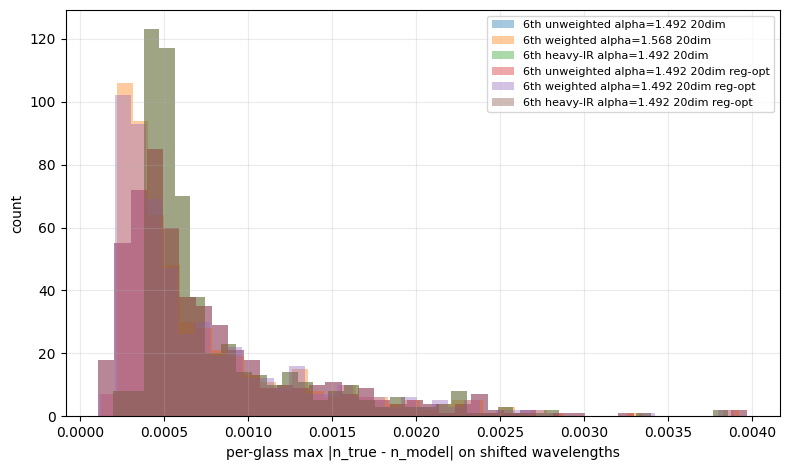

In [8]:
all_cases = cases6

for test_name, wths in [("training wavelengths", wavelengths), ("shifted wavelengths", wth_shift)]:
    print("\n" + "="*72)
    print(test_name)
    print("="*72)
    for name, order, alpha, A in all_cases:
        errs = end_to_end_errors_high(wths, alpha, A)
        print(f"{name:<46} max={errs.max():.4e} mean={errs.mean():.4e} median={np.median(errs):.4e} p95={np.percentile(errs, 95):.4e}")

fig, ax = plt.subplots(figsize=(8, 4.8))
for name, order, alpha, A in all_cases:
    errs = end_to_end_errors_high(wth_shift, alpha, A)
    ax.hist(errs, bins=40, alpha=0.4, label=name)
ax.set_xlabel("per-glass max |n_true - n_model| on shifted wavelengths")
ax.set_ylabel("count")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Per-Wavelength Error

This plot shows the 6th-order runtime regression error at each wavelength, summarized over all filtered glasses.


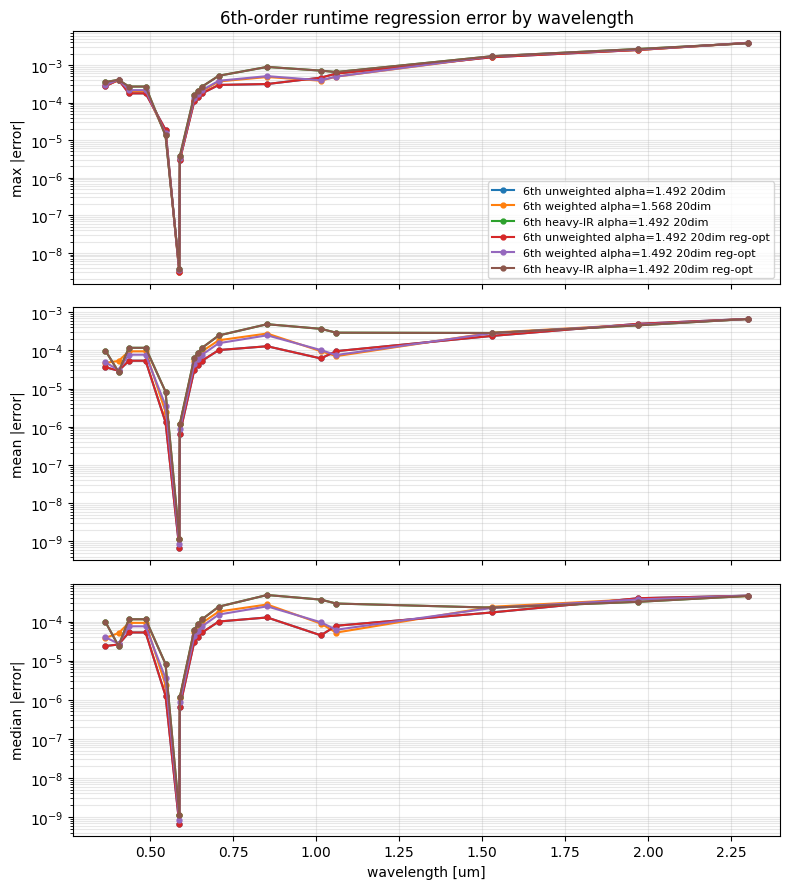

6th unweighted alpha=1.492 20dim reg-opt
wavelength_um   max_abs_err   mean_abs_err   median_abs_err
     0.36501  2.728746e-04   3.605045e-05     2.360046e-05
     0.40466  4.045961e-04   2.920249e-05     2.587852e-05
     0.43583  1.760664e-04   5.333755e-05     5.249194e-05
     0.48613  1.761170e-04   5.334670e-05     5.250133e-05
     0.54607  1.908250e-05   1.314931e-06     1.272374e-06
     0.58756  3.077878e-09   6.656749e-10     6.523735e-10
     0.58929  3.023734e-06   6.643914e-07     6.511326e-07
     0.63280  1.097079e-04   3.072227e-05     3.029435e-05
     0.64385  1.411227e-04   4.110432e-05     4.053291e-05
     0.65627  1.760982e-04   5.334164e-05     5.249635e-05
     0.70652  2.955121e-04   1.013547e-04     1.000461e-04
     0.85211  3.124035e-04   1.275990e-04     1.270390e-04
     1.01398  4.613244e-04   6.121422e-05     4.438171e-05
     1.06000  5.917811e-04   9.492670e-05     7.803041e-05
     1.52958  1.615619e-03   2.377441e-04     1.707954e-04
     1.97009  

In [9]:
def per_wavelength_error_stats(wths, alpha, A, feature_func=feature_vec_20):
    errors = []
    for g in glasses_filtered:
        n_true = get_indices(g, wths)
        n_pred = predict_from_regression_high(g, wths, alpha, A, feature_func)
        errors.append(np.abs(n_true - n_pred))
    errors = np.vstack(errors)
    return {
        "max": errors.max(axis=0),
        "mean": errors.mean(axis=0),
        "median": np.median(errors, axis=0),
    }

fig, axes = plt.subplots(3, 1, figsize=(8, 9), sharex=True)
stat_names = ["max", "mean", "median"]

for name, order, alpha, A in cases6:
    stats = per_wavelength_error_stats(wavelengths, alpha, A)
    for ax, stat_name in zip(axes, stat_names):
        ax.semilogy(wavelengths, stats[stat_name], marker="o", ms=3.5, label=name)
        ax.set_ylabel(f"{stat_name} |error|")
        ax.grid(True, which="both", alpha=0.3)

axes[-1].set_xlabel("wavelength [um]")
axes[0].set_title("6th-order runtime regression error by wavelength")
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

# Numeric table for the regression-optimized 6th-order candidate.
reg_opt_case = next((case for case in cases6 if "reg-opt" in case[0]), cases6[-1])
name, order, alpha, A = reg_opt_case
stats = per_wavelength_error_stats(wavelengths, alpha, A)
print(name)
print("wavelength_um   max_abs_err   mean_abs_err   median_abs_err")
for w, max_err, mean_err, med_err in zip(wavelengths, stats["max"], stats["mean"], stats["median"]):
    print(f"{w:12.5f} {max_err:13.6e} {mean_err:14.6e} {med_err:16.6e}")


## H-LAF3B Diagnostic


In [10]:
def find_glass(name):
    key = name.upper()
    return [g for g in glasses_filtered if key in g["name"].upper()]


matches = find_glass("H-LAF3B")
if matches:
    g = matches[0]
    n_true_155 = float(get_indices(g, np.array([1.55]))[0])
    print(g["catalog"], g["name"])
    print("true n(1.55):", f"{n_true_155:.10f}")

    for name, order, alpha, A in all_cases:
        phi = feature_vec_20(g["nd"], g["vd"], g["dPgF"])
        nu_high = phi @ A
        n_pred = float(predict_self_consistent_high(g["nd"], g["vd"], g["dPgF"], nu_high, np.array([1.55]), alpha)[0])

        nu_tail_zeroed = nu_high.copy()
        nu_tail_zeroed[2:] = 0.0
        n_pred_without_tail = float(predict_self_consistent_high(g["nd"], g["vd"], g["dPgF"], nu_tail_zeroed, np.array([1.55]), alpha)[0])

        print("\n" + name)
        print(f"  n={n_pred:.10f}, err={n_pred - n_true_155:+.4e}")
        print(f"  predicted nu3..nu{order} =", np.array2string(nu_high, precision=6, suppress_small=False))
        print(f"  with nu5..nu{order}=0: n={n_pred_without_tail:.10f}, delta={n_pred_without_tail - n_pred:+.4e}")


cdgm H-LAF3B
true n(1.55): 1.7185450039

6th unweighted alpha=1.492 20dim
  n=1.7177329103, err=-8.1209e-04
  predicted nu3..nu6 = [-0.086996  0.255581 -0.164489 -1.337315]
  with nu5..nu6=0: n=1.7241514567, delta=+6.4185e-03

6th weighted alpha=1.568 20dim
  n=1.7178401472, err=-7.0486e-04
  predicted nu3..nu6 = [-0.073411  0.384365 -0.145019 -2.131093]
  with nu5..nu6=0: n=1.7251512200, delta=+7.3111e-03

6th heavy-IR alpha=1.492 20dim
  n=1.7178513452, err=-6.9366e-04
  predicted nu3..nu6 = [-0.107803  0.435068  0.034151 -2.121427]
  with nu5..nu6=0: n=1.7245264176, delta=+6.6751e-03

6th unweighted alpha=1.492 20dim reg-opt
  n=1.7177329103, err=-8.1209e-04
  predicted nu3..nu6 = [-0.086996  0.255581 -0.164489 -1.337315]
  with nu5..nu6=0: n=1.7241514567, delta=+6.4185e-03

6th weighted alpha=1.492 20dim reg-opt
  n=1.7178359588, err=-7.0905e-04
  predicted nu3..nu6 = [-0.09335   0.327457 -0.09668  -1.653753]
  with nu5..nu6=0: n=1.7245048559, delta=+6.6689e-03

6th heavy-IR alpha=

## Anchor Consistency Test


In [11]:
for name, order, alpha, A in all_cases:
    max_nd = 0.0
    max_vd = 0.0
    max_dpgf = 0.0
    for g in glasses_filtered:
        phi = feature_vec_20(g["nd"], g["vd"], g["dPgF"])
        nu_high = phi @ A
        nd_m, vd_m, dpgf_m = anchor_report_high(g["nd"], g["vd"], g["dPgF"], nu_high, alpha)
        max_nd = max(max_nd, abs(nd_m - g["nd"]))
        max_vd = max(max_vd, abs(vd_m - g["vd"]))
        max_dpgf = max(max_dpgf, abs(dpgf_m - g["dPgF"]))
    print(f"{name:<46} max anchor errors: nd={max_nd:.3e}, Vd={max_vd:.3e}, dPgF={max_dpgf:.3e}")


6th unweighted alpha=1.492 20dim               max anchor errors: nd=0.000e+00, Vd=8.043e-12, dPgF=1.051e-13
6th weighted alpha=1.568 20dim                 max anchor errors: nd=0.000e+00, Vd=9.052e-12, dPgF=1.291e-13
6th heavy-IR alpha=1.492 20dim                 max anchor errors: nd=0.000e+00, Vd=6.679e-12, dPgF=1.094e-13
6th unweighted alpha=1.492 20dim reg-opt       max anchor errors: nd=0.000e+00, Vd=8.043e-12, dPgF=1.051e-13
6th weighted alpha=1.492 20dim reg-opt         max anchor errors: nd=0.000e+00, Vd=5.940e-12, dPgF=1.588e-13
6th heavy-IR alpha=1.492 20dim reg-opt         max anchor errors: nd=0.000e+00, Vd=6.679e-12, dPgF=1.094e-13


## Save Regression Matrices


In [12]:
np.save("regression_buchdahl_nu3456_20dim_self_consistent_unweighted_opt.npy", A6_ref_opt_20)
np.save("regression_buchdahl_nu3456_20dim_self_consistent_unweighted_reg_opt.npy", A6_ref_reg_opt_20)
np.save("regression_buchdahl_nu3456_20dim_self_consistent_weighted_opt.npy", A6_opt_20)
np.save("regression_buchdahl_nu3456_20dim_self_consistent_weighted_reg_opt.npy", A6_reg_opt_20)
np.save("regression_buchdahl_nu3456_20dim_self_consistent_heavy_ir_opt.npy", A6_heavy_opt_20)
np.save("regression_buchdahl_nu3456_20dim_self_consistent_heavy_ir_reg_opt.npy", A6_heavy_reg_opt_20)

with open("regression_buchdahl_self_consistent_high_order_metadata.txt", "w", encoding="utf-8") as f:
    f.write(f"BASE_WEIGHT_STRENGTH={BASE_WEIGHT_STRENGTH:.12g}\n")
    f.write(f"BASE_WEIGHT_POWER={BASE_WEIGHT_POWER:.12g}\n")
    f.write(f"HEAVY_IR_START={HEAVY_IR_START:.12g}\n")
    f.write(f"HEAVY_IR_STRENGTH={HEAVY_IR_STRENGTH:.12g}\n")
    f.write(f"HEAVY_IR_POWER={HEAVY_IR_POWER:.12g}\n")
    f.write(f"ALPHA6_REF_OPT={ALPHA6_REF_OPT:.12g}\n")
    f.write(f"ALPHA6_REF_REG_OPT={ALPHA6_REF_REG_OPT:.12g}\n")
    f.write(f"ALPHA6_OPT={ALPHA6_OPT:.12g}\n")
    f.write(f"ALPHA6_REG_OPT={ALPHA6_REG_OPT:.12g}\n")
    f.write(f"ALPHA6_HEAVY_OPT={ALPHA6_HEAVY_OPT:.12g}\n")
    f.write(f"ALPHA6_HEAVY_REG_OPT={ALPHA6_HEAVY_REG_OPT:.12g}\n")
    f.write("Algorithm=6th-order self-consistent nu12 solved conditioned on predicted/fitted nu3..nu6\n")
    f.write("Profiles=unweighted, weighted distance-from-d-line, heavy-IR weighted\n")
    f.write("6th-order coefficients: nu3..nu6\n")

print("Saved unweighted, weighted, and heavy-IR 6th-order regression matrices.")
print(f"ALPHA6_REF_OPT = {ALPHA6_REF_OPT:.6f}")
print(f"ALPHA6_REF_REG_OPT = {ALPHA6_REF_REG_OPT:.6f}")
print(f"ALPHA6_OPT = {ALPHA6_OPT:.6f}")
print(f"ALPHA6_REG_OPT = {ALPHA6_REG_OPT:.6f}")
print(f"ALPHA6_HEAVY_OPT = {ALPHA6_HEAVY_OPT:.6f}")
print(f"ALPHA6_HEAVY_REG_OPT = {ALPHA6_HEAVY_REG_OPT:.6f}")


Saved unweighted, weighted, and heavy-IR 6th-order regression matrices.
ALPHA6_REF_OPT = 1.491525
ALPHA6_REF_REG_OPT = 1.491525
ALPHA6_OPT = 1.567797
ALPHA6_REG_OPT = 1.491525
ALPHA6_HEAVY_OPT = 1.491525
ALPHA6_HEAVY_REG_OPT = 1.491525


## Runtime Formula For `ModelMaterial`

For the 6th-order runtime model:

1. Choose one trained regression matrix: unweighted reference, distance-weighted, or heavy-IR weighted.
2. Compute $[\nu_3, \nu_4, \nu_5, \nu_6] = \phi(n_d,V_d,\Delta P_{g,F})A_{3456}$.
3. Solve $\nu_1,\nu_2$ with `solve_nu12_conditioned_high`, subtracting every high-order contribution from the F-C and g-F anchor equations.
4. Return $[\nu_1, \nu_2, \nu_3, \nu_4, \nu_5, \nu_6]$.
5. Evaluate:

$$
n(\lambda) = n_d + \sum_{k=1}^{6}\nu_k\omega^k
$$

`ModelMaterial._get_coefficients()` must return all six coefficients. The final polynomial evaluator must use every returned coefficient; otherwise the extra fitted terms are silently discarded.

The weighting only changes how the regression matrix is trained. Runtime evaluation is unchanged: after a selected matrix predicts $\nu_3..\nu_6$, the same self-consistent anchor solve gives $\nu_1,\nu_2$.

Use the unweighted matrix as the reference. If far-from-d-line wavelengths are more important, compare the distance-weighted and heavy-IR weighted regression-optimized matrices.
